# import and ennvironment

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from visualizations import lineplots_4x4
from processing import filter_region
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
from noise_seeds import noise_iterations

# load prediction arrays, create array objects

In [2]:
def load_arrs(arr_type: str, folder_path):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [3]:
folder_path_stochbin = 'predictions/8-27-2025/'
folder_path_sigma10 = 'predictions/sigma10'

In [4]:
stochbin_sum = load_arrs('sum', folder_path_stochbin)
stochbin_mean = load_arrs('mean', folder_path_stochbin)
stochbin_var = load_arrs('var', folder_path_stochbin)
stochbin_label = load_arrs('label', folder_path_stochbin)

In [5]:
# load for those in sigma10
"""
later need to make this generalize to different systems
"""
sigma10_sum = np.load(folder_path_sigma10 + "/sum_sigma10.npy")
sigma10_mean = np.load(folder_path_sigma10 + "/mean_sigma10.npy")
sigma10_var = np.load(folder_path_sigma10 + "/var_sigma10.npy")
sigma10_label = np.load(folder_path_sigma10 + "/labels_sigma10.npy")

# get mean and var arrays from V1
filtering done as well

get region 1 here

In [6]:
v1mean_stochbin = filter_region(1, stochbin_label, stochbin_mean)
v1var_stochbin = filter_region(1, stochbin_label, stochbin_var)

"""
NOTE USING LABELS FROM V1MEAN TO FILTER HERE, ASSUMING THIS IS FINE SINCE IT IS THE SAME NEURONS 
"""

v1mean_sigma10 = filter_region(1, stochbin_label, sigma10_mean)
v1var_sigma10 = filter_region(1, stochbin_label, sigma10_var)

In [7]:
# delete 9 grey images

v1mean_sigma10 = v1mean_sigma10[9:, ...]
v1var_sigma10 = v1var_sigma10[9:,...]
v1mean_stochbin = v1mean_stochbin[9:,...]
v1var_stochbin = v1var_stochbin[9:,...]

# remove values

after 11/20 meeting removing anything >100

In [8]:
mask_gaus = v1mean_sigma10 <= 100
mask_bernoulli = v1mean_stochbin <= 100

In [9]:
v1mean_sigma10[~mask_gaus] = np.nan
v1var_sigma10[~mask_gaus] = np.nan
v1mean_stochbin[~mask_bernoulli] = np.nan
v1var_stochbin[~mask_bernoulli] = np.nan

# get indices to sort

In [10]:
stochbin_med = np.nanmedian(v1mean_stochbin, axis = 0)
sigma10_med = np.nanmedian(v1mean_sigma10, axis = 0)

In [11]:
stochbin_sort_indices = np.argsort(stochbin_med)[::-1]
sigma10_sort_indices = np.argsort(sigma10_med)[::-1]

In [12]:
stochbin_meanv1 = v1mean_stochbin[..., stochbin_sort_indices]
stochbin_varv1 = v1var_stochbin[..., stochbin_sort_indices]

sigma10_meanv1 = v1mean_sigma10[..., sigma10_sort_indices]
sigma10_varv1 = v1var_sigma10[..., sigma10_sort_indices]

# Figure 1

In [13]:
from scipy.stats import linregress

mean_masked, var_masked = stochbin_meanv1, stochbin_varv1
main_title ="variance = a*mean^b\\Bernoulli (neurons 1-16)"

# pre allocate statistics 
stochbin_medians = []
stochbin_alist = []
stochbin_blist = []
stochbin_rsqlist = []

neurons = [i for i in range(16)]
for neuron in range(mean_masked.shape[1]):
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    med = np.median(x)
    
    # Filter out non-positive and non-finite values BEFORE taking log
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        stochbin_alist.append(0)
        stochbin_blist.append(np.nan)
        stochbin_rsqlist.append(np.nan)
        stochbin_medians.append(med)
        continue
    
    x_m = x[mask]
    y_m = y[mask]
    logx = np.log(x_m)
    logy = np.log(y_m)

    # Verify no NaNs before regression
    if not (np.isfinite(logx).all() and np.isfinite(logy).all()):
        stochbin_alist.append(0)
        stochbin_blist.append(np.nan)
        stochbin_rsqlist.append(np.nan)
        stochbin_medians.append(med)
        continue

    # Zero-intercept regression in log-space: log(y) = b*log(x)
    model = LinearRegression(fit_intercept=False)
    model.fit(logx.reshape(-1, 1), logy)
    b = model.coef_[0]
    a = 0  # Forced to zero intercept in log-space
    y_pred = model.predict(logx.reshape(-1, 1))
    ss_res = np.sum((logy - y_pred)**2)
    ss_tot = np.sum((logy - np.mean(logy))**2)
    r_squared = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    stochbin_medians.append(med)
    stochbin_alist.append(a)  # Now 0 for zero-intercept
    stochbin_blist.append(b)
    stochbin_rsqlist.append(r_squared)
stochbin_alist = np.exp(stochbin_alist)


#---now do for sigma=10 dynamic gaussian noise---
sigma10_medians = []
sigma10_alist = []
sigma10_blist = []
sigma10_rsqlist = []

mean_masked, var_masked = sigma10_meanv1, sigma10_varv1
neurons = [i for i in range(16)]
for neuron in range(mean_masked.shape[1]):
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    med = np.median(x)
    
    # Filter out non-positive and non-finite values BEFORE taking log
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        sigma10_alist.append(0)
        sigma10_blist.append(np.nan)
        sigma10_rsqlist.append(np.nan)
        sigma10_medians.append(med)
        continue
    
    x_m = x[mask]
    y_m = y[mask]
    logx = np.log(x_m)
    logy = np.log(y_m)

    # Verify no NaNs before regression
    if not (np.isfinite(logx).all() and np.isfinite(logy).all()):
        sigma10_alist.append(0)
        sigma10_blist.append(np.nan)
        sigma10_rsqlist.append(np.nan)
        sigma10_medians.append(med)
        continue

    # Zero-intercept regression in log-space: log(y) = b*log(x)
    model = LinearRegression(fit_intercept=False)
    model.fit(logx.reshape(-1, 1), logy)
    b = model.coef_[0]
    a = 0  # Forced to zero intercept in log-space
    y_pred = model.predict(logx.reshape(-1, 1))
    ss_res = np.sum((logy - y_pred)**2)
    ss_tot = np.sum((logy - np.mean(logy))**2)
    r_squared = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    sigma10_medians.append(med)
    sigma10_alist.append(a)  # Now 0 for zero-intercept
    sigma10_blist.append(b)
    sigma10_rsqlist.append(r_squared)
sigma10_alist = np.exp(sigma10_alist)


def r2_fixed_line(a, b, x, y):
    """
    Compute R^2 for the model y_hat = a + b*x
    given fixed parameters a and b.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    y_hat = a + b * x
    
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    
    # If variance is zero, define R^2 = 1 if perfect, else 0
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    
    return 1 - ss_res / ss_tot

pooled_stochbin = [r2_fixed_line(a, b, x, y) for a, b, x, y in zip(stochbin_alist, stochbin_blist, stochbin_rsqlist, stochbin_varv1.mean(axis=0))]
pooled_sigma10 = [r2_fixed_line(a, b, x, y) for a, b, x, y in zip(sigma10_alist, sigma10_blist, sigma10_rsqlist, sigma10_varv1.mean(axis=0))]

# Replace r2_fixed_line with a proper log-space R^2 calculator
def r2_global_params(a_log, b, mean_array, var_array):
    """
    Compute R^2 for log(y) = a_log + b*log(x) using global parameters
    on a single neuron's data.
    """
    x = np.asarray(mean_array).flatten()
    y = np.asarray(var_array).flatten()
    
    # Mask valid data
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    
    x = x[mask]
    y = y[mask]
    
    # Log-space predictions
    log_x = np.log(x)
    log_y = np.log(y)
    log_y_hat = a_log + b * log_x
    
    # R^2 in log-space
    ss_res = np.sum((log_y - log_y_hat)**2)
    ss_tot = np.sum((log_y - np.mean(log_y))**2)
    
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    
    return 1 - ss_res / ss_tot

# Compute pooled R^2 per neuron using GLOBAL parameters from pooled fit
pooled_stochbin = []
pooled_sigma10 = []

# Use global parameters from earlier pooled fit (cell #VSC-0c31f10c)
# If not available, compute them here
x_all_st = stochbin_meanv1.flatten()
y_all_st = stochbin_varv1.flatten()
mask_st = (x_all_st > 0) & (y_all_st > 0) & np.isfinite(x_all_st) & np.isfinite(y_all_st)
b_glob_st, a_glob_st, _, _, _ = linregress(np.log(x_all_st[mask_st]), np.log(y_all_st[mask_st]))

x_all_sg = sigma10_meanv1.flatten()
y_all_sg = sigma10_varv1.flatten()
mask_sg = (x_all_sg > 0) & (y_all_sg > 0) & np.isfinite(x_all_sg) & np.isfinite(y_all_sg)
b_glob_sg, a_glob_sg, _, _, _ = linregress(np.log(x_all_sg[mask_sg]), np.log(y_all_sg[mask_sg]))

# Compute per-neuron R^2 using global parameters
for neuron in range(stochbin_meanv1.shape[-1]):
    r2 = r2_global_params(a_glob_st, b_glob_st, stochbin_meanv1[:, neuron], stochbin_varv1[:, neuron])
    pooled_stochbin.append(r2)

for neuron in range(sigma10_meanv1.shape[-1]):
    r2 = r2_global_params(a_glob_sg, b_glob_sg, sigma10_meanv1[:, neuron], sigma10_varv1[:, neuron])
    pooled_sigma10.append(r2)

pooled_stochbin = np.array(pooled_stochbin)
pooled_sigma10 = np.array(pooled_sigma10)
# Per-neuron log-log fits: collect a, b, and R^2 (r_val**2) for stochbin and sigma10
# Extended: also collect linear-space power-law fits y = a*x^b (a_lin, b_lin, R^2_lin) per neuron.

from scipy.optimize import curve_fit

def smooth_func(x, a, b):
    return a * (x**b)

# Containers (log-space: kept compatible with downstream code)
stochbin_alist_log, stochbin_blist_log, stochbin_rsqlist_log = [], [], []
sigma10_alist_log,   sigma10_blist_log,   sigma10_rsqlist_log   = [], [], []

# Containers (linear-space)
stochbin_alist_lin, stochbin_blist_lin, stochbin_rsqlist_lin = [], [], []
sigma10_alist_lin,   sigma10_blist_lin,   sigma10_rsqlist_lin   = [], [], []

# Determine neuron count from available arrays (prefer v1 arrays if present)
if 'stochbin_meanv1' in globals():
    n_neurons = stochbin_meanv1.shape[-1]
    mean_st, var_st = stochbin_meanv1, stochbin_varv1
else:
    n_neurons = stochbin_mean.shape[-1]
    mean_st, var_st = stochbin_mean, stochbin_var

if 'sigma10_meanv1' in globals():
    n_neurons_s = sigma10_meanv1.shape[-1]
    mean_sg, var_sg = sigma10_meanv1, sigma10_varv1
else:
    n_neurons_s = sigma10_mean.shape[-1]
    mean_sg, var_sg = sigma10_mean, sigma10_var

def fit_log_power(x, y):
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan  # a_log (=1 for zero-intercept), b_log, r2_log
    lx = np.log(x[mask]); ly = np.log(y[mask])
    # Zero-intercept regression: log(y) = b*log(x), so y = x^b, a=1
    model = LinearRegression(fit_intercept=False)
    model.fit(lx.reshape(-1, 1), ly)
    b = model.coef_[0]
    y_pred = model.predict(lx.reshape(-1, 1))
    ss_res = np.sum((ly - y_pred)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return 1.0, b, r2  # Returns a=1.0 (zero-intercept in log-space), b, r2

def fit_lin_power(x, y, a_initial = 1.0, b_initial = 1e-3):
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan  # a_lin, b_lin, r2_lin
    xm = x[mask]; ym = y[mask]
    try:
        params, _ = curve_fit(smooth_func, xm, ym, maxfev=1_000_000, p0=[a_initial, b_initial])
        a_lin, b_lin = params
        y_hat = smooth_func(xm, a_lin, b_lin)
        ss_res = np.sum((ym - y_hat)**2)
        ss_tot = np.sum((ym - np.mean(ym))**2)
        r2_lin = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return a_lin, b_lin, r2_lin
    except Exception:
        return np.nan, np.nan, np.nan

# --- stochbin per-neuron fits ---
for neuron in range(n_neurons):
    x = mean_st[..., neuron].astype(float)
    y = var_st[..., neuron].astype(float)
    # log-space fit
    a_log, b_log, r2_log = fit_log_power(x, y)
    stochbin_alist_log.append(a_log)
    stochbin_blist_log.append(b_log)
    stochbin_rsqlist_log.append(r2_log)
    # linear-space fit
    initiala_bern, initialb_bern = 2.5e-3, 2.23 # hard code initial guesses
    a_lin, b_lin, r2_lin = fit_lin_power(x, y, a_initial=initiala_bern, b_initial = initialb_bern)
    stochbin_alist_lin.append(a_lin)
    stochbin_blist_lin.append(b_lin)
    stochbin_rsqlist_lin.append(r2_lin)

# --- sigma10 per-neuron fits ---
for neuron in range(n_neurons_s):
    x = mean_sg[..., neuron].astype(float)
    y = var_sg[..., neuron].astype(float)
    # log-space fit
    a_log, b_log, r2_log = fit_log_power(x, y)
    sigma10_alist_log.append(a_log)
    sigma10_blist_log.append(b_log)
    sigma10_rsqlist_log.append(r2_log)
    # linear-space fit
    initiala_gaus, initialb_gaus = 2.2e-4, 2.24 
    a_lin, b_lin, r2_lin = fit_lin_power(x, y, a_initial = initiala_gaus, b_initial = initialb_gaus)
    sigma10_alist_lin.append(a_lin)
    sigma10_blist_lin.append(b_lin)
    sigma10_rsqlist_lin.append(r2_lin)

# Convert to numpy arrays
stochbin_alist      = np.array(stochbin_alist_log)   # log-space a (exp intercept)
stochbin_blist      = np.array(stochbin_blist_log)   # log-space b (slope)
stochbin_rsqlist    = np.array(stochbin_rsqlist_log) # log-space R^2
stochbin_alist_lin  = np.array(stochbin_alist_lin)   # linear-space a
stochbin_blist_lin  = np.array(stochbin_blist_lin)   # linear-space b
stochbin_rsqlist_lin= np.array(stochbin_rsqlist_lin) # linear-space R^2

sigma10_alist       = np.array(sigma10_alist_log)
sigma10_blist       = np.array(sigma10_blist_log)
sigma10_rsqlist     = np.array(sigma10_rsqlist_log)
sigma10_alist_lin   = np.array(sigma10_alist_lin)
sigma10_blist_lin   = np.array(sigma10_blist_lin)
sigma10_rsqlist_lin = np.array(sigma10_rsqlist_lin)

# --- Global pooled model per-neuron R^2 lists (zero-intercept LinearRegression, log-space) ---
stochbin_global_r2_list = []
sigma10_global_r2_list = []

for neuron in range(n_neurons):
    x = mean_st[..., neuron].astype(float)
    y = var_st[..., neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        stochbin_global_r2_list.append(np.nan)
        continue
    x_m = x[mask]; y_m = y[mask]
    # Verify no NaNs before regression
    if not (np.isfinite(x_m).all() and np.isfinite(y_m).all()):
        stochbin_global_r2_list.append(np.nan)
        continue
    lx = np.log(x_m); ly = np.log(y_m)
    model = LinearRegression(fit_intercept=False)
    model.fit(lx.reshape(-1, 1), ly)
    y_pred = model.predict(lx.reshape(-1, 1))
    ss_res = np.sum((ly - y_pred)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    stochbin_global_r2_list.append(r2)

for neuron in range(n_neurons_s):
    x = mean_sg[..., neuron].astype(float)
    y = var_sg[..., neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        sigma10_global_r2_list.append(np.nan)
        continue
    x_m = x[mask]; y_m = y[mask]
    # Verify no NaNs before regression
    if not (np.isfinite(x_m).all() and np.isfinite(y_m).all()):
        sigma10_global_r2_list.append(np.nan)
        continue
    lx = np.log(x_m); ly = np.log(y_m)
    model = LinearRegression(fit_intercept=False)
    model.fit(lx.reshape(-1, 1), ly)
    y_pred = model.predict(lx.reshape(-1, 1))
    ss_res = np.sum((ly - y_pred)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    sigma10_global_r2_list.append(r2)

stochbin_global_r2_list = np.array(stochbin_global_r2_list)
sigma10_global_r2_list = np.array(sigma10_global_r2_list)

# --- Individual neuron LINEAR MODEL R^2 (y = mx + b) ---
from scipy.stats import linregress  # Import linregress for linear model fits
stochbin_rsqlist_lin_model = []
sigma10_rsqlist_lin_model = []

# Determine neuron count and arrays
if 'stochbin_meanv1' in globals():
    n_neurons = stochbin_meanv1.shape[-1]
    mean_st, var_st = stochbin_meanv1, stochbin_varv1
else:
    n_neurons = stochbin_mean.shape[-1]
    mean_st, var_st = stochbin_mean, stochbin_var

if 'sigma10_meanv1' in globals():
    n_neurons_s = sigma10_meanv1.shape[-1]
    mean_sg, var_sg = sigma10_meanv1, sigma10_varv1
else:
    n_neurons_s = sigma10_mean.shape[-1]
    mean_sg, var_sg = sigma10_mean, sigma10_var

# Fit simple linear model y = mx + b for each neuron (stochbin)
for neuron in range(n_neurons):
    x = mean_st[..., neuron].astype(float).flatten()
    y = var_st[..., neuron].astype(float).flatten()
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        stochbin_rsqlist_lin_model.append(np.nan)
        continue
    slope, intercept, r_val, p_val, std_err = linregress(x[mask], y[mask])
    stochbin_rsqlist_lin_model.append(r_val**2)

# Fit simple linear model y = mx + b for each neuron (sigma10)
for neuron in range(n_neurons_s):
    x = mean_sg[..., neuron].astype(float).flatten()
    y = var_sg[..., neuron].astype(float).flatten()
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        sigma10_rsqlist_lin_model.append(np.nan)
        continue
    slope, intercept, r_val, p_val, std_err = linregress(x[mask], y[mask])
    sigma10_rsqlist_lin_model.append(r_val**2)

stochbin_rsqlist_lin_model = np.array(stochbin_rsqlist_lin_model)
sigma10_rsqlist_lin_model = np.array(sigma10_rsqlist_lin_model)

# --- Pooled LINEAR MODEL R^2 (y = mx + b) ---
# Fit global linear model on all data, then compute per-neuron R^2
from scipy.stats import linregress

# Global linear fit on all stochbin data
x_all_st = mean_st.flatten()
y_all_st = var_st.flatten()
mask_all_st = (x_all_st > 0) & (y_all_st > 0) & np.isfinite(x_all_st) & np.isfinite(y_all_st)
if mask_all_st.sum() >= 2:
    slope_glob_st, intercept_glob_st, _, _, _ = linregress(x_all_st[mask_all_st], y_all_st[mask_all_st])
else:
    slope_glob_st, intercept_glob_st = np.nan, np.nan

# Global linear fit on all sigma10 data
x_all_sg = mean_sg.flatten()
y_all_sg = var_sg.flatten()
mask_all_sg = (x_all_sg > 0) & (y_all_sg > 0) & np.isfinite(x_all_sg) & np.isfinite(y_all_sg)
if mask_all_sg.sum() >= 2:
    slope_glob_sg, intercept_glob_sg, _, _, _ = linregress(x_all_sg[mask_all_sg], y_all_sg[mask_all_sg])
else:
    slope_glob_sg, intercept_glob_sg = np.nan, np.nan

# Compute per-neuron R^2 using global linear model (stochbin)
pooled_stochbin_lin_model = []
for neuron in range(n_neurons):
    x = mean_st[..., neuron].astype(float).flatten()
    y = var_st[..., neuron].astype(float).flatten()
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        pooled_stochbin_lin_model.append(np.nan)
        continue
    x_m = x[mask]
    y_m = y[mask]
    y_hat = slope_glob_st * x_m + intercept_glob_st
    ss_res = np.sum((y_m - y_hat)**2)
    ss_tot = np.sum((y_m - np.mean(y_m))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    pooled_stochbin_lin_model.append(r2)

# Compute per-neuron R^2 using global linear model (sigma10)
pooled_sigma10_lin_model = []
for neuron in range(n_neurons_s):
    x = mean_sg[..., neuron].astype(float).flatten()
    y = var_sg[..., neuron].astype(float).flatten()
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        pooled_sigma10_lin_model.append(np.nan)
        continue
    x_m = x[mask]
    y_m = y[mask]
    y_hat = slope_glob_sg * x_m + intercept_glob_sg
    ss_res = np.sum((y_m - y_hat)**2)
    ss_tot = np.sum((y_m - np.mean(y_m))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    pooled_sigma10_lin_model.append(r2)

pooled_stochbin_lin_model = np.array(pooled_stochbin_lin_model)
pooled_sigma10_lin_model = np.array(pooled_sigma10_lin_model)

print(f'LINEAR MODEL (y=mx+b) R^2 ranges:')
print(f'  stochbin individual: {np.nanmin(stochbin_rsqlist_lin_model):.3f} - {np.nanmax(stochbin_rsqlist_lin_model):.3f}')
print(f'  sigma10 individual:  {np.nanmin(sigma10_rsqlist_lin_model):.3f} - {np.nanmax(sigma10_rsqlist_lin_model):.3f}')
print(f'  stochbin pooled:     {np.nanmin(pooled_stochbin_lin_model):.3f} - {np.nanmax(pooled_stochbin_lin_model):.3f}')
print(f'  sigma10 pooled:      {np.nanmin(pooled_sigma10_lin_model):.3f} - {np.nanmax(pooled_sigma10_lin_model):.3f}')

LINEAR MODEL (y=mx+b) R^2 ranges:
  stochbin individual: 0.076 - 0.971
  sigma10 individual:  0.014 - 0.954
  stochbin pooled:     -292868.977 - 0.935
  sigma10 pooled:      -44627.511 - 0.908


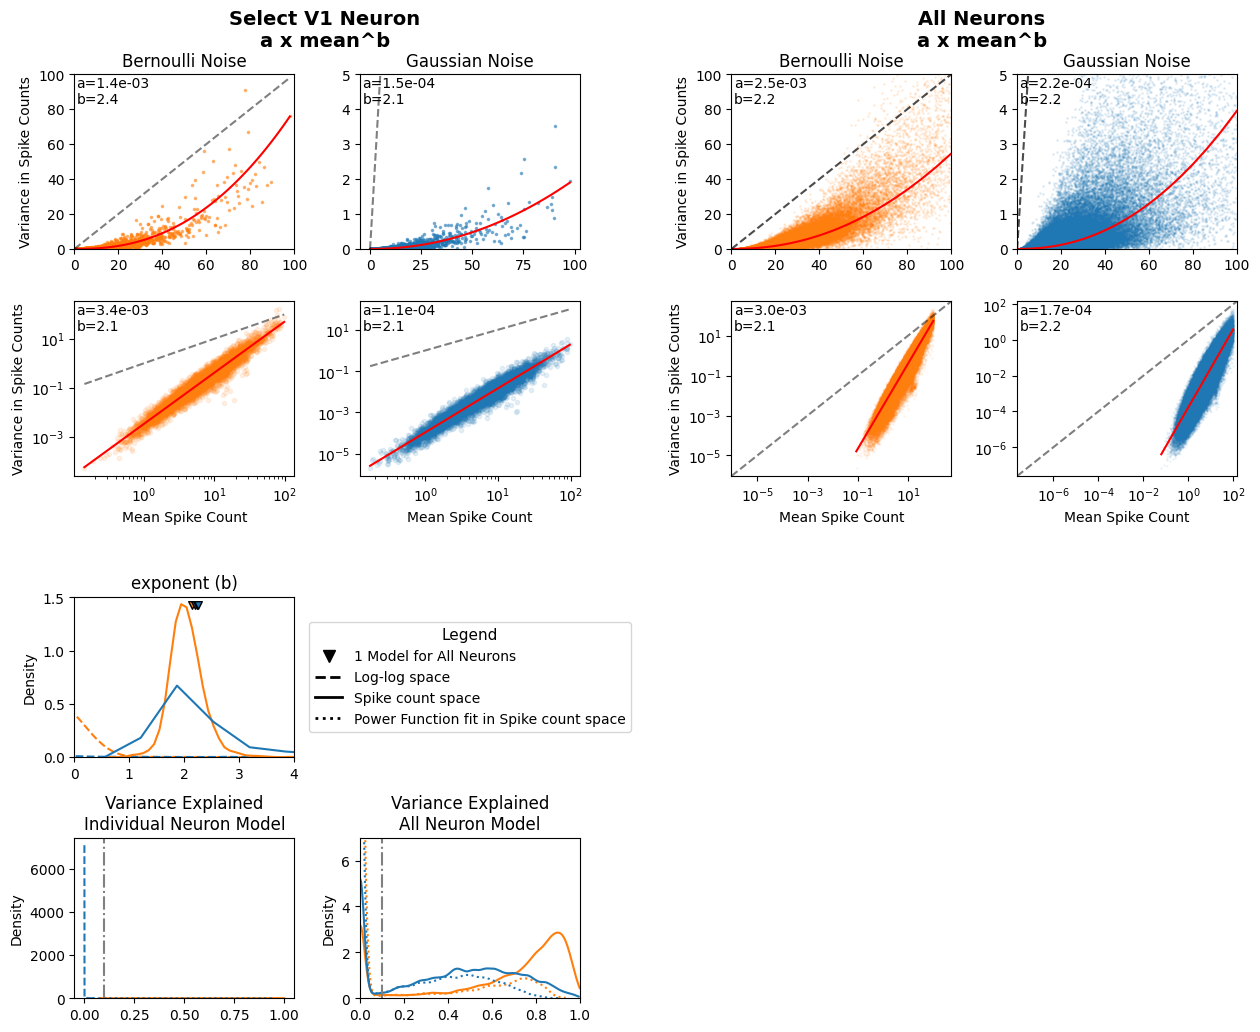

In [ ]:
# Helper functions
def smooth_from_logfit(x, log_intercept, b):
    a = np.exp(log_intercept)
    return a * (x ** b)

def axb_noslope (x, a, b):
    return a*(x**b)

def safe_mask(x, y):
    xa = np.asarray(x).astype(float).flatten()
    ya = np.asarray(y).astype(float).flatten()
    mask = (xa > 0) & (ya > 0) & np.isfinite(xa) & np.isfinite(ya)
    return xa[mask], ya[mask]

# Create figure
fig = plt.figure(figsize=(15, 12))
outer = gridspec.GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.3)

# --- TOP LEFT: Neuron 3 (2x2 nested) ---
inner_tl = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0, 0], wspace=0.3, hspace=0.3)
neuron_idx = 2 # Neuron 3

# Data for Neuron 3
xg, yg = safe_mask(sigma10_meanv1[neuron_idx], sigma10_varv1[neuron_idx])
xb, yb = safe_mask(stochbin_meanv1[neuron_idx], stochbin_varv1[neuron_idx])

# Fits for Gaussian
if xg.size > 1:
    # Log-log fit (for log axes) - WITH intercept
    logxg = np.log(xg); logyg = np.log(yg)
    if np.isfinite(logxg).all() and np.isfinite(logyg).all():
        model_g = LinearRegression(fit_intercept=True)
        model_g.fit(logxg.reshape(-1, 1), logyg)
        class LogFitResult:
            def __init__(self, slope, intercept):
                self.slope = slope
                self.intercept = intercept
        res_g = LogFitResult(model_g.coef_[0], model_g.intercept_)
        xg_fit_log = np.exp(np.linspace(np.log(xg.min()), np.log(xg.max()), 100))
        yg_fit_log = smooth_from_logfit(xg_fit_log, res_g.intercept, res_g.slope)
    else:
        xg_fit_log, yg_fit_log = [], []
    
    # Curve fit for linear space
    params_g, _ = curve_fit(axb_noslope, xg, yg, maxfev=1_000_000, p0=[1, 0.001])
    xg_fit_lin = np.linspace(xg.min(), xg.max(), 100)
    yg_fit_lin = smooth_from_logfit(xg_fit_lin, np.log(params_g[0]), params_g[1])
else:
    xg_fit_log, yg_fit_log = [], []
    xg_fit_lin, yg_fit_lin = [], []

# Fits for Bernoulli
if xb.size > 1:
    # Log-log fit - WITH intercept
    logxb = np.log(xb); logyb = np.log(yb)
    if np.isfinite(logxb).all() and np.isfinite(logyb).all():
        model_b = LinearRegression(fit_intercept=True)
        model_b.fit(logxb.reshape(-1, 1), logyb)
        # Create result-like object for compatibility
        class LogFitResult:
            def __init__(self, slope, intercept):
                self.slope = slope
                self.intercept = intercept
        res_b = LogFitResult(model_b.coef_[0], model_b.intercept_)
        xb_fit_log = np.exp(np.linspace(np.log(xb.min()), np.log(xb.max()), 100))
        yb_fit_log = smooth_from_logfit(xb_fit_log, res_b.intercept, res_b.slope)
    else:
        res_b = None
        xb_fit_log, yb_fit_log = [], []
    
    params_b, _ = curve_fit(axb_noslope, xb, yb, maxfev=1_000_000, p0=[1, 0.001])
    xb_fit_lin = np.linspace(xb.min(), xb.max(), 100)
    yb_fit_lin = smooth_from_logfit(xb_fit_lin, np.log(params_b[0]), params_b[1])
else:
    xb_fit_log, yb_fit_log = [], []
    xb_fit_lin, yb_fit_lin = [], []

# Compute pooled R^2 per neuron using GLOBAL parameters from LINEAR-SPACE pooled fit
pooled_stochbin_lin = []
pooled_sigma10_lin = []

# Fit global linear-space model on all stochbin data
x_all_st_lin = stochbin_meanv1.flatten()
y_all_st_lin = stochbin_varv1.flatten()
mask_st_lin = (x_all_st_lin > 0) & (y_all_st_lin > 0) & np.isfinite(x_all_st_lin) & np.isfinite(y_all_st_lin)
try:
    params_glob_st_lin, _ = curve_fit(axb_noslope, x_all_st_lin[mask_st_lin], y_all_st_lin[mask_st_lin], 
                                      maxfev=1_000_000, p0=[1, 0.001])
    a_glob_st_lin, b_glob_st_lin = params_glob_st_lin
except:
    a_glob_st_lin, b_glob_st_lin = np.nan, np.nan

# Fit global linear-space model on all sigma10 data
x_all_sg_lin = sigma10_meanv1.flatten()
y_all_sg_lin = sigma10_varv1.flatten()
mask_sg_lin = (x_all_sg_lin > 0) & (y_all_sg_lin > 0) & np.isfinite(x_all_sg_lin) & np.isfinite(y_all_sg_lin)
try:
    params_glob_sg_lin, _ = curve_fit(axb_noslope, x_all_sg_lin[mask_sg_lin], y_all_sg_lin[mask_sg_lin],
                                      maxfev=1_000_000, p0=[1, 0.001])
    a_glob_sg_lin, b_glob_sg_lin = params_glob_sg_lin
except:
    a_glob_sg_lin, b_glob_sg_lin = np.nan, np.nan

# Compute per-neuron R^2 using global LINEAR parameters for stochbin
for neuron in range(stochbin_meanv1.shape[-1]):
    x = stochbin_meanv1[:, neuron].astype(float)
    y = stochbin_varv1[:, neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        pooled_stochbin_lin.append(np.nan)
        continue
    x_m = x[mask]
    y_m = y[mask]
    y_hat = axb_noslope(x_m, a_glob_st_lin, b_glob_st_lin)
    ss_res = np.sum((y_m - y_hat)**2)
    ss_tot = np.sum((y_m - np.mean(y_m))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    pooled_stochbin_lin.append(r2)

# Compute per-neuron R^2 using global LINEAR parameters for sigma10
for neuron in range(sigma10_meanv1.shape[-1]):
    x = sigma10_meanv1[:, neuron].astype(float)
    y = sigma10_varv1[:, neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        pooled_sigma10_lin.append(np.nan)
        continue
    x_m = x[mask]
    y_m = y[mask]
    y_hat = axb_noslope(x_m, a_glob_sg_lin, b_glob_sg_lin)
    ss_res = np.sum((y_m - y_hat)**2)
    ss_tot = np.sum((y_m - np.mean(y_m))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    pooled_sigma10_lin.append(r2)

pooled_stochbin_lin = np.array(pooled_stochbin_lin)
pooled_sigma10_lin = np.array(pooled_sigma10_lin)

# TL Subplots
# 1. Gaussian Linear
ax = fig.add_subplot(inner_tl[0, 1])
ax.scatter(xg, yg, s=10, label='Data', marker=".", alpha=0.5)
ax.plot(xg_fit_lin, yg_fit_lin, "r-", label='Fit')
ax.plot([0, xg.max()], [0, xg.max()], 'k--', alpha=0.5)
ax.set_title("Gaussian Noise")
if len(xg_fit_lin):
    ax.text(0.01, 0.99, f"a={params_g[0]:.1e}\nb={params_g[1]:.1f}", 
            transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)
ax.set_ylim(0, 5)
bbox = ax.get_position()
label = f"a x mean^b"

fig.text(bbox.x1 - .17,  # x-coordinate (centered)
         bbox.y1 + 0.02,              # y-coordinate (above the plot)
         f"Select V1 Neuron\n{label}",
         ha='center',                 # horizontal alignment
         va='bottom',                 # vertical alignment
         fontsize=14,
         fontweight='bold',
         transform=fig.transFigure)


# 2. Gaussian Log (use log fits)
ax = fig.add_subplot(inner_tl[1, 1])
ax.loglog(xg, yg, '.', label='Data', alpha=0.1)
if len(xg_fit_log): ax.loglog(xg_fit_log, yg_fit_log, 'r-', label='Fit')
ax.plot([xg.min(), xg.max()], [xg.min(), xg.max()], 'k--', alpha=0.5)
ax.set_xlabel('Mean Spike Count')
ax.text(0.01, 0.99, f"a={np.exp(res_g.intercept):.1e}\nb={res_g.slope:.1f}", 
        transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)

# 3. Bernoulli Linear
ax = fig.add_subplot(inner_tl[0, 0])
ax.scatter(xb, yb, s=10, color='tab:orange', label='Data', marker=".", alpha=0.5)
if len(xb_fit_lin): ax.plot(xb_fit_lin, yb_fit_lin, 'r-', label='Fit')
ax.plot([0, xb.max()], [0, xb.max()], 'k--', alpha=0.5)
ax.set_ylabel('Variance in Spike Counts')
ax.set_title("Bernoulli Noise")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
if len(xb_fit_lin):
    ax.text(0.01, 0.99, f"a={params_b[0]:.1e}\nb={params_b[1]:.1f}", 
            transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)

# 4. Bernoulli Log
ax = fig.add_subplot(inner_tl[1, 0])
ax.loglog(xb, yb, '.', color='tab:orange', label='Data', alpha=0.1)
if len(xb_fit_log): ax.loglog(xb_fit_log, yb_fit_log, 'r-', label='Fit')
ax.plot([xb.min(), xb.max()], [xb.min(), xb.max()], 'k--', alpha=0.5)
ax.set_xlabel('Mean Spike Count')
ax.set_ylabel("Variance in Spike Counts")
ax.text(0.01, 0.99, f"a={np.exp(res_b.intercept):.1e}\nb={res_b.slope:.1f}", 
        transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)

# --- TOP RIGHT: All Neurons (2x2 nested) ---
inner_tr = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0, 1], wspace=0.3, hspace=0.3)

# Data for All
xg_all, yg_all = safe_mask(sigma10_meanv1, sigma10_varv1)
xb_all, yb_all = safe_mask(stochbin_meanv1, stochbin_varv1)
# ...existing code...
# Fits
if xg_all.size > 1:
    # Log-log fit - WITH intercept
    logxg_all = np.log(xg_all); logyg_all = np.log(yg_all)
    model_ga = LinearRegression(fit_intercept=True)
    model_ga.fit(logxg_all.reshape(-1, 1), logyg_all)
    # Compute rvalue for result object
    y_pred_ga = model_ga.predict(logxg_all.reshape(-1, 1))
    ss_res_ga = np.sum((logyg_all - y_pred_ga)**2)
    ss_tot_ga = np.sum((logyg_all - np.mean(logyg_all))**2)
    # Clamp R² to [0,1] before taking sqrt to avoid negative values
    r2_ga = np.clip(1 - ss_res_ga/ss_tot_ga, 0, 1) if ss_tot_ga > 0 else 0
    r_value_ga = np.sqrt(r2_ga)
    # Create result-like object for compatibility
    class LogFitResult:
        def __init__(self, slope, intercept, rvalue):
            self.slope = slope
            self.intercept = intercept
            self.rvalue = rvalue
    res_ga = LogFitResult(model_ga.coef_[0], model_ga.intercept_, r_value_ga)
    xg_fit_a = np.exp(np.linspace(np.log(xg_all.min()), np.log(xg_all.max()), 100))
    yg_fit_a = smooth_from_logfit(xg_fit_a, res_ga.intercept, res_ga.slope)
    # optional: linear-space fit for separate b on linear panel
    try:
        params_ga_lin, _ = curve_fit(axb_noslope, xg_all, yg_all, maxfev=1_000_000, p0=[1, 0.001])
    except Exception:
        params_ga_lin = [np.nan, np.nan]
else:
    xg_fit_a, yg_fit_a = [], []
    params_ga_lin = [np.nan, np.nan]

if xb_all.size > 1:
    # Log-log fit - WITH intercept
    logxb_all = np.log(xb_all); logyb_all = np.log(yb_all)
    model_ba = LinearRegression(fit_intercept=True)
    model_ba.fit(logxb_all.reshape(-1, 1), logyb_all)
    # Compute rvalue for result object
    y_pred_ba = model_ba.predict(logxb_all.reshape(-1, 1))
    ss_res_ba = np.sum((logyb_all - y_pred_ba)**2)
    ss_tot_ba = np.sum((logyb_all - np.mean(logyb_all))**2)
    # Clamp R² to [0,1] before taking sqrt to avoid negative values
    r2_ba = np.clip(1 - ss_res_ba/ss_tot_ba, 0, 1) if ss_tot_ba > 0 else 0
    r_value_ba = np.sqrt(r2_ba)
    res_ba = LogFitResult(model_ba.coef_[0], model_ba.intercept_, r_value_ba)
    xb_fit_a = np.exp(np.linspace(np.log(xb_all.min()), np.log(xb_all.max()), 100))
    yb_fit_a = smooth_from_logfit(xb_fit_a, res_ba.intercept, res_ba.slope)
    # optional: linear-space fit for separate b on linear panel
    try:
        params_ba_lin, _ = curve_fit(axb_noslope, xb_all, yb_all, maxfev=1_000_000, p0=[1, 0.001])
    except Exception:
        params_ba_lin = [np.nan, np.nan]
else:
    xb_fit_a, yb_fit_a = [], []
    params_ba_lin = [np.nan, np.nan]

# TR Subplots
# 1. Gaussian Linear
ax = fig.add_subplot(inner_tr[0, 1])
ax.scatter(xg_all, yg_all, s=1, alpha=0.1)
if len(xg_fit_a): ax.plot(xg_fit_a, yg_fit_a, 'r-')
ax.plot([0, xg_all.max()], [0, xg_all.max()], 'k--', alpha=0.7)
ax.set_title('Gaussian Noise')
# Show linear-space parameters for linear plot
a_lin_g = params_ga_lin[0]
b_lin_g = params_ga_lin[1]
ax.text(0.01, 0.99, f"a={a_lin_g:.1e}\nb={b_lin_g:.1f}",
        transform=ax.transAxes, va='top', ha='left', fontsize=10)
ax.margins(0)
ax.set_xlim(0,100)
ax.set_ylim(0, 5)

# Add title above TR plot
bbox = ax.get_position()
label = f"a x mean^b"
fig.text(bbox.x1 - .17,  # x-coordinate (centered)
         bbox.y1 + 0.02,              # y-coordinate (above the plot)
         f"All Neurons\n{label}",
         ha='center',                 # horizontal alignment
         va='bottom',                 # vertical alignment
         fontsize=14,
         fontweight='bold',
         transform=fig.transFigure)

# Gaussian Log - force axes to start at same point
ax = fig.add_subplot(inner_tr[1, 1])
ax.loglog(xg_all, yg_all, '.', markersize=1, alpha=0.1)
if len(xg_fit_a): ax.loglog(xg_fit_a, yg_fit_a, 'r-')
# Get current limits and find common minimum
xlim = ax.get_xlim()
ylim = ax.get_ylim()
common_min = min(xlim[0], ylim[0])
common_max = max(xlim[1], ylim[1])
# Set both axes to same range so origin aligns
ax.set_xlim(common_min, common_max)
ax.set_ylim(common_min, common_max)
# Now draw diagonal from true axis limits
ax.plot([common_min, common_max], [common_min, common_max], 'k--', alpha=0.5)
ax.set_xlabel("Mean Spike Count")
# Add a and b parameters for log-space Gaussian
ax.text(0.01, 0.99, f"a={np.exp(res_ga.intercept):.1e}\nb={res_ga.slope:.1f}",
        transform=ax.transAxes, va='top', ha='left', fontsize=10)
ax = fig.add_subplot(inner_tr[1, 0])
ax.loglog(xb_all, yb_all, '.', markersize=1, alpha=0.1, color='tab:orange')
if len(xb_fit_a): ax.loglog(xb_fit_a, yb_fit_a, 'r-')
# Get current limits and find common minimum
xlim = ax.get_xlim()
ylim = ax.get_ylim()
common_min = min(xlim[0], ylim[0])
common_max = max(xlim[1], ylim[1])
# Set both axes to same range
ax.set_xlim(common_min, common_max)
ax.set_ylim(common_min, common_max)
# Draw diagonal from true axis limits
ax.plot([common_min, common_max], [common_min, common_max], 'k--', alpha=0.5)
ax.set_xlabel("Mean Spike Count")
ax.set_ylabel("Variance in Spike Counts")
# Add a and b parameters for log-space Bernoulli
ax.text(0.01, 0.99, f"a={np.exp(res_ba.intercept):.1e}\nb={res_ba.slope:.1f}",
        transform=ax.transAxes, va='top', ha='left', fontsize=10)


# 3. Bernoulli Linear
ax = fig.add_subplot(inner_tr[0, 0])
ax.scatter(xb_all, yb_all, s=1, alpha=0.1, color='tab:orange')
if len(xb_fit_a): ax.plot(xb_fit_a, yb_fit_a, 'r-')
ax.plot([0, xb_all.max()], [0, xb_all.max()], 'k--', alpha=0.7)
ax.set_title('Bernoulli Noise')
ax.set_ylabel('Variance in Spike Counts')
# Show linear-space parameters for linear plot
a_lin_b = params_ba_lin[0]
b_lin_b = params_ba_lin[1]
ax.text(0.01, 0.99, f"a={a_lin_b:.1e}\nb={b_lin_b:.1f}",
        transform=ax.transAxes, va='top', ha='left', fontsize=10)
ax.set_ylim(0, 100)
ax.set_xlim(0, 100)
ax.margins(0)

# --- BOTTOM LEFT: KDE ---

# get a and b for top right regression
pooled_a_gaussian = np.exp(res_ga.intercept) if xg_all.size > 1 else np.nan
pooled_b_gaussian = res_ga.slope if xg_all.size > 1 else np.nan
pooled_a_bernoulli = np.exp(res_ba.intercept) if xb_all.size > 1 else np.nan
pooled_b_bernoulli = res_ba.slope if xb_all.size > 1 else np.nan
pooled_rsq_gaussian = res_ga.rvalue**2 if xg_all.size > 1 else np.nan
pooled_rsq_bernoulli = res_ba.rvalue**2 if xb_all.size > 1 else np.nan

# get indices of neurons with variance explained > thresh
def above_threshold(r2_array, thresh=0.1):
    r2 = np.asarray(r2_array, float)
    mask = np.isfinite(r2) & (r2 > thresh)
    return np.where(mask)[0]
ve_thresh = 0.1

ve_idx_gaus = above_threshold(sigma10_rsqlist_lin, ve_thresh)
ve_idx_bern = above_threshold(stochbin_rsqlist_lin, ve_thresh)

# Change to 2x2 grid
inner = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[1,0], wspace=0.3, hspace=0.5)

# [0,0] - B PLOT (slope distribution)
ax = fig.add_subplot(inner[0, 0])
sns.kdeplot(stochbin_blist[ve_idx_bern], linestyle = "--", label="Log Log Space", color="tab:orange", ax=ax)
sns.kdeplot(sigma10_blist[ve_idx_gaus], ax=ax, linestyle = "--"
            )
sns.kdeplot(stochbin_blist_lin[ve_idx_bern], label="Spike Count Space", color="tab:orange", ax=ax)
sns.kdeplot(sigma10_blist_lin[ve_idx_gaus], bw_adjust = 0.05, color="tab:blue", ax=ax)

ax.set_title("exponent (b)")
ax.set_xlim(0, 4)
current_ylim = ax.get_ylim()
y_top = current_ylim[1] * 0.95  # Position triangles at 95% of max y

# Plot pooled markers with downward triangles at the top
if np.isfinite(pooled_b_bernoulli):
    ax.scatter(pooled_b_bernoulli, y_top, marker="v", s=30, edgecolor="k",
                 color="tab:orange", label="Bernoulli pooled (log-log)", zorder=5)

if np.isfinite(pooled_b_gaussian):
    ax.scatter(pooled_b_gaussian, y_top, marker="v", s=30, edgecolor="k",
                 color="tab:blue", label="Gaussian pooled (log-log)", zorder=5)
    
if np.isfinite(b_glob_st_lin):
    ax.scatter(b_glob_st_lin, y_top, marker="v", s=30, edgecolor="k",
                 color="tab:orange", label="Bernoulli pooled (linear)", zorder=5)

if np.isfinite(b_glob_sg_lin):
    ax.scatter(b_glob_sg_lin, y_top, marker="v", s=30, edgecolor="k",
                 color="tab:blue", label="Gaussian pooled (linear)", zorder=5)

# [1,0] - R^2 PLOT (individual fits) - SIX LINES
ax = fig.add_subplot(inner[1, 0])

def clean(arr, clip01=True):
    v = np.asarray(arr, float)
    v = v[np.isfinite(v)]
    if clip01:
        v = np.clip(v, 0, 1)
    return v

def kde_r2(ax, arr, label, color, ls="-"):
    v = clean(arr, clip01=True)
    if v.size < 3:
        ax.text(0.05, 0.9, f"{label}: n={v.size}", transform=ax.transAxes)
        return
    sns.kdeplot(v, ax=ax, label=label, color=color, linestyle=ls,
                bw_adjust=0.35, cut=0, clip=(0, 1), common_norm=False)

# Bernoulli (orange)
kde_r2(ax, stochbin_rsqlist_lin,        "Bernoulli: power law (linear space)",      "tab:orange", "-")
#kde_r2(ax, stochbin_rsqlist,            "Bernoulli: power law (log-log regression)","tab:orange", "--")
kde_r2(ax, stochbin_rsqlist_lin_model,  "Bernoulli: linear model (y=mx+b)",         "tab:orange", ":")

# Gaussian (blue)
kde_r2(ax, sigma10_rsqlist,         "Gaussian: power law (linear space)",       "tab:blue", "--")
#kde_r2(ax, sigma10_rsqlist_lin,             "Gaussian: power law (log-log regression)", "tab:blue", "-")
kde_r2(ax, sigma10_rsqlist_lin_model,   "Gaussian: linear model (y=mx+b)",          "tab:blue", ":")

ax.axvline(x=ve_thresh, color="0.5", linestyle = "dashdot")
ax.set_title("Variance Explained\nIndividual Neuron Model")
#ax.set_xlim(0, 1.0)

# [1,1] - R^2 PLOT (pooled/all neurons) - SIX LINES
ax = fig.add_subplot(inner[1, 1])

kde_r2(ax, pooled_stochbin_lin,        "Bernoulli: power law pooled (linear space)",      "tab:orange", "-")
#kde_r2(ax, pooled_stochbin,            "Bernoulli: power law pooled (log-log regression)","tab:orange", "--")
kde_r2(ax, pooled_stochbin_lin_model,  "Bernoulli: linear model pooled (y=mx+b)",         "tab:orange", ":")

#kde_r2(ax, pooled_sigma10,             "Gaussian: power law pooled (log-log regression)", "tab:blue", "--")
kde_r2(ax, pooled_sigma10_lin,         "Gaussian: power law pooled (linear space)",       "tab:blue", "-")
kde_r2(ax, pooled_sigma10_lin_model,   "Gaussian: linear model pooled (y=mx+b)",          "tab:blue", ":")
ax.axvline(x=ve_thresh, color="0.5", linestyle = "dashdot")
ax.set_title("Variance Explained\nAll Neuron Model")
ax.set_xlim(0, 1.0)
ax.set_ylim(0,7)

# [0,1] - Legend panel (optional: keep off or remove entirely)
ax = fig.add_subplot(inner[0, 1])
ax.axis('off')
# ...existing code...
# Create dummy elements for legend
# [0,1] - Legend
ax = fig.add_subplot(inner[0, 1])
ax.axis('off')  # Turn off axis

# Create dummy elements for legend
legend_elements = [
    Line2D([0], [0], marker='v', color='k', label='1 Model for All Neurons',
           markerfacecolor='k', markersize=8, linestyle='None', markeredgecolor='k'),
    Line2D([0], [0], color='k', linewidth=2, linestyle = "--", label='Log-log space'),
    Line2D([0], [0], color='k', linewidth=2,  label='Spike count space'),
    Line2D([0], [0], color='k', linewidth=2, linestyle=':', label='Power Function fit in Spike count space')

]
# Place legend in center of subplot
ax.legend(handles=legend_elements, loc='center', frameon=True, fontsize=10, title='Legend', title_fontsize=11)
plt.show()

# pixel space plot

In [15]:
image_df = np.load("image_stacks/imagestack_nov232025(first100).npy") # note using first 100 here

def get_noise_per_image(img, num_frames, num_noise_seeds, noise_type: str, sigma: int, stoch_bin_param):
    if img.ndim != 3: img = np.array(img).reshape((1, img.shape[0], img.shape[1]))
    tiled_img = np.tile(img, (num_frames, 1, 1))
    return np.array(noise_iterations("_", "_", noise_type, num_noise_seeds, tiled_img, sigma, stochastic_bin_param=stoch_bin_param, 
                                     scans=[[4,7]], num_frames=num_frames, return_noise=True))

num_imgs=100
num_noise_seeds=10
num_frames=15
noise_arr_gaus = np.empty((num_imgs, num_noise_seeds, num_frames, 144, 256))
noise_arr_bern = np.empty((num_imgs, num_noise_seeds, num_frames, 144, 256))

In [16]:
for i in range(num_imgs): noise_arr_gaus[i] = get_noise_per_image(image_df[i], num_frames, num_noise_seeds, "dynamic", 10, False)
for i in range(num_imgs): noise_arr_bern[i] = get_noise_per_image(image_df[i], num_frames, num_noise_seeds, "dynamic", 10, True)

In [ ]:
noise_arr_fg = noise_arr_gaus.reshape(num_imgs, num_noise_seeds, num_frames, 144*256).astype(np.float32)
print()
noise_arr_fg = np.sum(noise_arr_fg, axis = 2)
fg_mean = np.mean(noise_arr_fg, axis=1).flatten()
fg_var = np.var(noise_arr_fg, axis=1).flatten()

noise_arr_fb = noise_arr_bern.reshape(num_imgs, num_noise_seeds, num_frames, 144*256).astype(np.float32)
noise_arr_fb = np.sum(noise_arr_fb, axis = 2)
fb_mean = np.mean(noise_arr_fb, axis=1).flatten()
fb_var = np.var(noise_arr_fb, axis=1).flatten()


In [ ]:
# get RELU data here
noise_arr_fg = noise_arr_gaus.reshape(num_imgs, num_noise_seeds, num_frames, 144*256).astype(np.float32)
print("shape before summing:", noise_arr_fg.shape)
##NEED TO SUM HERE##
fg_relu = np.where(noise_arr_fg>=128, noise_arr_fg, 0)
fg_mean_relu = np.mean(fg_relu, axis=1).flatten()
fg_var_relu = np.var(fg_relu, axis=1).flatten()

noise_arr_fb = noise_arr_bern.reshape(num_imgs, num_noise_seeds, num_frames, 144*256).astype(np.float32)
fb_relu = np.where(noise_arr_fb>=128, noise_arr_fb, 0)
fb_mean_relu = np.mean(fb_relu, axis=1).flatten()
fb_var_relu = np.var(fb_relu, axis=1).flatten()

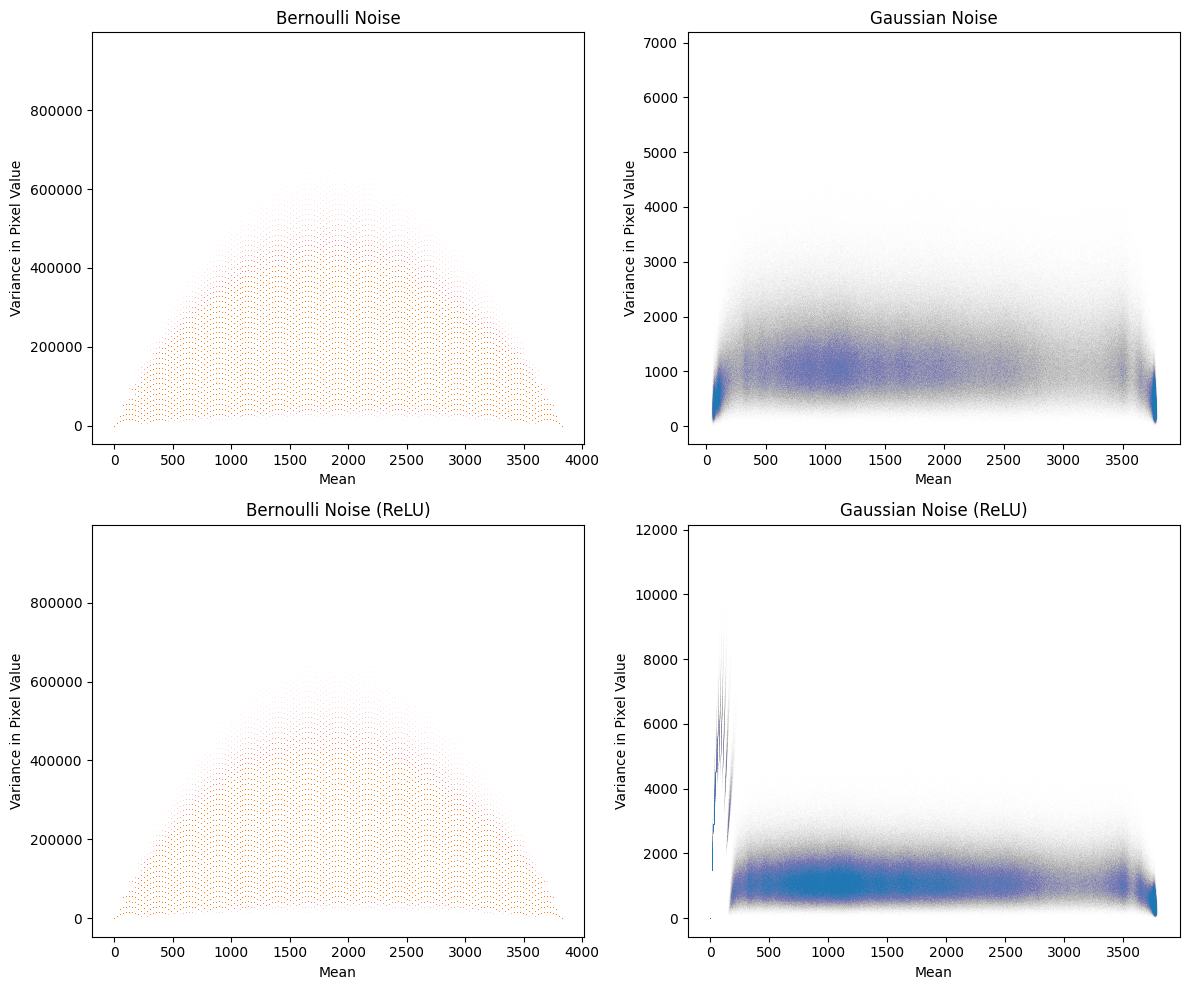

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Left column: Bernoulli
axes[0, 0].scatter(fb_mean, fb_var, marker=".", alpha=0.0025, s=1.001, color='tab:orange')
axes[0, 0].set_xlabel("Mean")
axes[0, 0].set_ylabel("Variance in Pixel Value")
axes[0, 0].set_title("Bernoulli Noise")

axes[1, 0].scatter(fb_mean_relu, fb_var_relu, marker=".", alpha=0.0025, s=1.001, color='tab:orange')
axes[1, 0].set_xlabel("Mean")
axes[1, 0].set_ylabel("Variance in Pixel Value")
axes[1, 0].set_title("Bernoulli Noise (ReLU)")
axes[1,0].set_ylim(0, 60000)

# Right column: Gaussian
axes[0, 1].scatter(fg_mean, fg_var, marker=".", alpha=0.0025, s=1.001, color='tab:blue')
axes[0, 1].set_xlabel("Mean")
axes[0, 1].set_ylabel("Variance in Pixel Value")
axes[0, 1].set_title("Gaussian Noise")

axes[1, 1].scatter(fg_mean_relu, fg_var_relu, marker=".", alpha=0.0025, s=1.001, color='tab:blue')
axes[1, 1].set_xlabel("Mean")
axes[1, 1].set_ylabel("Variance in Pixel Value")
axes[1, 1].set_title("Gaussian Noise (ReLU)")

plt.tight_layout()
plt.show()